## Veri Ön İşleme 

In [13]:
import pandas as pd
import numpy as np

print("Laperlao Veri Ön İşleme Başlıyor...")

# 1. Veriyi Yükle (Noktalı virgül ile ayrıldığını görmüştük)
df = pd.read_csv("yorumsepeti.csv", sep=";", on_bad_lines="skip")

# 2. Eksik ve Hatalı Verileri Temizle
# Yorum metni (review) hiç yazılmamış olan satırları atıyoruz
df.dropna(subset=['review'], inplace=True)

# Hız, servis ve lezzet sütunlarındaki '-' gibi sayı olmayan karakterleri NaN (boş) değere çeviriyoruz
for col in ['speed', 'service', 'flavour']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Puanı eksik/hatalı olan satırları tamamen siliyoruz
df.dropna(subset=['speed', 'service', 'flavour'], inplace=True)

# 3. Ortalama Puanı Hesapla (Üç puanı toplayıp 3'e bölüyoruz)
df['ortalama_puan'] = df[['speed', 'service', 'flavour']].mean(axis=1)

# 4. Duygu (Sentiment) Etiketlerini Oluştur
# Puan 7 ve üstüyse Olumlu, 4-6 arası Nötr, 4'ten küçükse Olumsuz
def etiketle(puan):
    if puan >= 7:
        return 'Olumlu'
    elif puan >= 4:
        return 'Notr'
    else:
        return 'Olumsuz'

df['Duygu'] = df['ortalama_puan'].apply(etiketle)

# 5. Sadece Asistanın İhtiyacı Olan Sütunları Al
df_laperlao = df[['review', 'Duygu']].copy()
df_laperlao.rename(columns={'review': 'Yorum'}, inplace=True)

# Yeni veri setini kaydet
df_laperlao.to_csv("Laperlao_Hazir_Veri.csv", index=False)

print(f"İşlem Tamam! {len(df_laperlao)} adet tertemiz yorum 'Laperlao_Hazir_Veri.csv' olarak kaydedildi.")
print("\n--- Sınıf Dağılımı ---")
print(df_laperlao['Duygu'].value_counts())

Laperlao Veri Ön İşleme Başlıyor...
İşlem Tamam! 57292 adet tertemiz yorum 'Laperlao_Hazir_Veri.csv' olarak kaydedildi.

--- Sınıf Dağılımı ---
Duygu
Olumlu     46261
Olumsuz     5881
Notr        5150
Name: count, dtype: int64


## Model Eğitimi

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("1. Veriler yükleniyor...")
# Temizlediğimiz veriyi çağırıyoruz
df = pd.read_csv("Laperlao_Hazir_Veri.csv")
df.dropna(inplace=True) # Boşluk kalmışsa diye son bir güvenlik önlemi

# X: Öğreneceğimiz veriler (Yorumlar), y: Hedefimiz (Duygu)
X = df['Yorum']
y = df['Duygu']

print("2. Veri Test ve Eğitim olarak ikiye ayrılıyor...")
# Verinin %80'i eğitim için, %20'si modeli test etmek için ayrılıyor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("3. TF-IDF Vektörizasyonu başlıyor (Metinler sayılara çevriliyor)...")
# max_features=5000: Sadece en sık geçen 5000 kelimeyi al (bilgisayarı yormamak ve hızı artırmak için)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("4. Modeller Eğitiliyor... (Bu işlem bilgisayarının hızına göre 1-2 dakika sürebilir)")
# Ana Modelimiz: Random Forest
# n_jobs=-1 parametresi bilgisayarının tüm işlemci çekirdeklerini kullanıp eğitimi hızlandırır
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_vec, y_train)
rf_pred = rf_model.predict(X_test_vec)

# Karşılaştırma Modelimiz: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)
lr_pred = lr_model.predict(X_test_vec)




1. Veriler yükleniyor...
2. Veri Test ve Eğitim olarak ikiye ayrılıyor...
3. TF-IDF Vektörizasyonu başlıyor (Metinler sayılara çevriliyor)...
4. Modeller Eğitiliyor... (Bu işlem bilgisayarının hızına göre 1-2 dakika sürebilir)


## Sonuçlar Ve Performans

In [15]:
print("\n" + "="*40)
print("     RANDOM FOREST SONUÇLARI (ANA MODEL)")
print("="*40)
print(f"Accuracy (Doğruluk): % {accuracy_score(y_test, rf_pred) * 100:.2f}")
print(f"F1-Score (Ağırlıklı): % {f1_score(y_test, rf_pred, average='weighted') * 100:.2f}")
print("\nDetaylı Rapor:\n", classification_report(y_test, rf_pred))

print("\n" + "="*40)
print("  LOGISTIC REGRESSION SONUÇLARI (BASELINE)")
print("="*40)
print(f"Accuracy (Doğruluk): % {accuracy_score(y_test, lr_pred) * 100:.2f}")
print(f"F1-Score (Ağırlıklı): % {f1_score(y_test, lr_pred, average='weighted') * 100:.2f}")


     RANDOM FOREST SONUÇLARI (ANA MODEL)
Accuracy (Doğruluk): % 84.83
F1-Score (Ağırlıklı): % 81.09

Detaylı Rapor:
               precision    recall  f1-score   support

        Notr       0.35      0.05      0.09      1079
      Olumlu       0.87      0.98      0.93      9196
     Olumsuz       0.66      0.52      0.58      1184

    accuracy                           0.85     11459
   macro avg       0.63      0.52      0.53     11459
weighted avg       0.80      0.85      0.81     11459


  LOGISTIC REGRESSION SONUÇLARI (BASELINE)
Accuracy (Doğruluk): % 86.03
F1-Score (Ağırlıklı): % 83.93


## Karmaşıklık Matrisi


5. Karmaşıklık Matrisi (Confusion Matrix) Çiziliyor...
Grafik 'Confusion_Matrix.png' olarak kaydedildi! Sunumda kullanabilirsin.


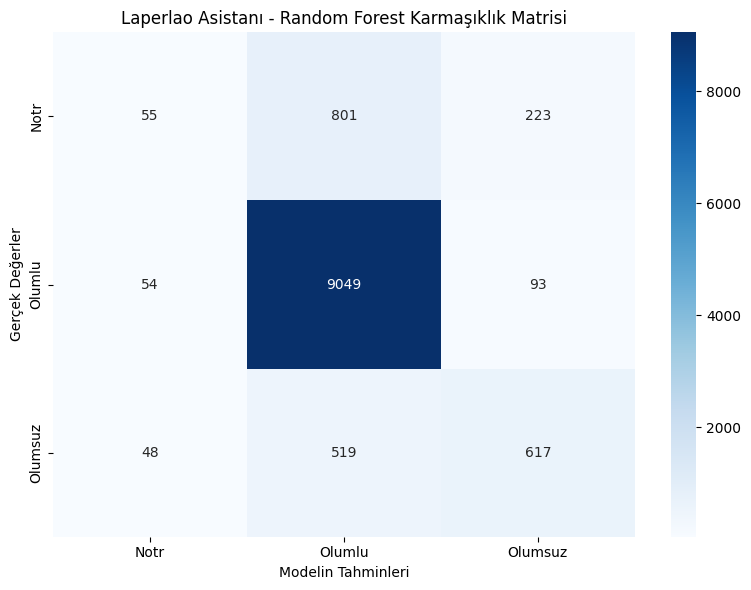

In [16]:

print("\n5. Karmaşıklık Matrisi (Confusion Matrix) Çiziliyor...")
# Sunumda kullanman için şık bir grafik oluşturuyoruz
cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Laperlao Asistanı - Random Forest Karmaşıklık Matrisi')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Modelin Tahminleri')
plt.tight_layout()
plt.savefig("Confusion_Matrix.png")
print("Grafik 'Confusion_Matrix.png' olarak kaydedildi! Sunumda kullanabilirsin.")

In [17]:
import joblib

# Modeli ve kelime çeviriciyi (vectorizer) ileride tekrar kullanmak için kaydediyoruz
joblib.dump(lr_model, 'Restoran_Asistan_Modeli.pkl')
joblib.dump(vectorizer, 'Restoran_Vectorizer.pkl')

print("Model ve Vectorizer başarıyla kaydedildi! Artık Restoran Asistanı eğitime ihtiyaç duymadan anında çalışabilir.")

Model ve Vectorizer başarıyla kaydedildi! Artık Restoran Asistanı eğitime ihtiyaç duymadan anında çalışabilir.
